Alle imports

In [13]:
import torch
import os
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch.utils.data
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil
import torchvision
from torchvision.transforms import (
    Compose,
    Lambda,
    RandomCrop,
    RandomHorizontalFlip,
    CenterCrop
)
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import cv2
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import mediapipe

In [14]:
NUM_FRAMES = 30
ROOT_FOLDER = "data/"
OUTPUT_FOLDER = "mp_landmarks/"
MEDIAPIPE_MODEL_PATH = "C:\\Users\\nikam\\ML2\\v1\\models\\hand_landmarker.task"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

In [15]:
BaseOptions = mediapipe.tasks.BaseOptions
HandLandmarker = mediapipe.tasks.vision.HandLandmarker
HandLandmarkerOptions = mediapipe.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mediapipe.tasks.vision.RunningMode

Funktion um landmarks für ein video zu extrahieren und speichern

In [16]:
def extract_landmarks(video_path : str, landmarker):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Video kann nicht geoeffnet werden: {video_path}")
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total_frames-1, NUM_FRAMES, dtype=int)
    
    landmarks = np.zeros((NUM_FRAMES, 21, 3), dtype=np.float32)
    for out, frame_i in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_i)
        ret, frame = cap.read()
        if not ret:
            break
        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mediapipe.Image(image_format=mediapipe.ImageFormat.SRGB, data= img_rgb)

        results = landmarker.detect(mp_image)
        if results.hand_landmarks:
            lms = results.hand_landmarks[0]
            coords = np.array([[l.x, l.y, l.z] for l in lms], dtype=np.float32)
            landmarks[out] = coords
    
    cap.release()

    return landmarks

In [17]:
def normalize_landmarks(seq):
    """
    seq: (T, 21, 3)
    Centers each frame at wrist (landmark 0), scales by wrist→middle-MCP distance (landmark 9).
    Returns (T, 21, 3) with values roughly in [-1, 1].
    """
    seq = seq.copy()
    wrist = seq[:, 0:1, :]                        # (T, 1, 3)
    seq -= wrist                                   # center at wrist
    scale = np.linalg.norm(seq[:, 9, :], axis=-1, keepdims=True)  # (T, 1)
    scale = np.maximum(scale, 1e-6)[:, :, None]   # (T, 1, 1) avoid div-by-zero
    seq /= scale
    return seq

Landmark extraction happens here

In [18]:
options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MEDIAPIPE_MODEL_PATH),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=1
)
with HandLandmarker.create_from_options(options) as landmarker:
    for split, csv_path in [("train", "train.csv"), ("val", "val.csv"), ("test", "test.csv")]:
        df = pd.read_csv(csv_path)
        rows = []
        for _, row in df.iterrows():
            landmarks = extract_landmarks(row['path'], landmarker)
            landmarks = normalize_landmarks(landmarks)
            npy_name = row["path"].replace("/","_").replace("\\","_") + ".npy"
            npy_path = os.path.join(OUTPUT_FOLDER, npy_name)
            np.save(npy_path, landmarks)
            rows.append({"path": row["path"], "label": row["label"], "npy_path": npy_path})
        pd.DataFrame(rows).to_csv(f"landmarks_{split}.csv", index=False)
        print(f"{split}: {len(rows)} videos processed")

train: 228 videos processed
val: 76 videos processed
test: 77 videos processed


Dataset Class

In [19]:
class HandLandmarkDataset(Dataset):
    def __init__(self, path):
        self.df = pd.read_csv(path)
        self.label_map = {"geste_0":0, "geste_1":1, "geste_2":2,
                 "class_1":3, "class_2":4, "Gesture01":5,
                 "Gesture02":6, "hand_turn":7, "ok_sign":8, "thumb_up":9}

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        seq = np.load(row['npy_path']).astype(np.float32)
        x = torch.from_numpy(seq.reshape(seq.shape[0], -1))
        y= self.label_map[row['label']]

        return x, torch.tensor(y, dtype=torch.long)

In [20]:
class LandmarkLSTM(nn.Module):
    def __init__(self, input_dim=63, hidden=128, layers=2, num_classes=10):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, layers,
                            batch_first=True, dropout=0.3, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden * 2, num_classes)
        )
    def forward(self, x):          # x: (B, T, 63)
        out, _ = self.lstm(x)
        return self.classifier(out[:, -1, :])

In [29]:
def train(EPOCHS : int):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = LandmarkLSTM().to(device=device)
    
    train_loader = DataLoader(HandLandmarkDataset("landmarks_train.csv"), batch_size=16, shuffle=True)
    val_loader = DataLoader(HandLandmarkDataset("landmarks_val.csv"), batch_size=16, shuffle=True)

    loss_criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
    best =0
    train_accs, val_accs = [], []
    for i in range(1, EPOCHS+1):
        model.train()
        train_loss, train_correct, train_total =0,0,0

        for videos, labels in train_loader:
            videos, labels = videos.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(videos)
            loss = loss_criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * videos.size(0)
            train_correct += (outputs.argmax(1)== labels).sum().item()
            train_total += videos.size(0)
        
        model.eval()
        val_correct, val_total = 0,0
        with torch.no_grad():
            for videos, labels in val_loader:
                videos, labels = videos.to(device), labels.to(device)
                outputs = model(videos)
                val_correct += (outputs.argmax(1)== labels).sum().item()
                val_total += labels.size(0)
        
        train_acc = train_correct / train_total
        val_acc   = val_correct / val_total * 100
        train_accs.append(train_acc * 100)
        val_accs.append(val_acc)

        if val_acc > best:
            best = val_acc
            torch.save(model.state_dict(), "models/mp_model.pth")

        if i % 10 ==0:
             print(f"Epoch {i:3d} | train acc: {train_acc*100:.1f}%  "
              f"val acc: {val_acc:.1f}%  (best: {best:.1f}%)")
    
    return train_accs, val_accs

In [30]:
train_accs, val_accs = train(50)

Epoch  10 | train acc: 97.4%  val acc: 96.1%  (best: 96.1%)
Epoch  20 | train acc: 100.0%  val acc: 100.0%  (best: 100.0%)
Epoch  30 | train acc: 100.0%  val acc: 100.0%  (best: 100.0%)
Epoch  40 | train acc: 100.0%  val acc: 100.0%  (best: 100.0%)
Epoch  50 | train acc: 100.0%  val acc: 100.0%  (best: 100.0%)


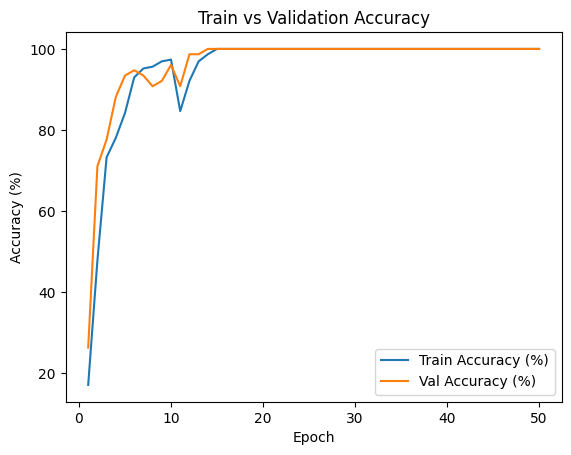

In [31]:
train_accs_pct = [acc * 100 for acc in train_accs]  # convert to %

fig, ax = plt.subplots()
ax.plot(range(1, len(train_accs) + 1), train_accs, label="Train Accuracy (%)")
ax.plot(range(1, len(val_accs) + 1), val_accs, label="Val Accuracy (%)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Train vs Validation Accuracy")
ax.legend()
plt.show()

In [ ]:

df = pd.read_csv("train.csv")
for label in ["geste_0", "geste_1", "geste_2", "class_1", "class_2", "Gesture01", "Gesture02"]:
    path = df[df["label"] == label].iloc[0]["path"]
    cap  = cv2.VideoCapture(path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // 2)
    ret, frame = cap.read()
    if ret:
        cv2.imshow(f"{label} — {path}", frame)
        cv2.waitKey(0)
    cap.release()
